# Single-Energy EXFOR Fitting and Sampling Demo

This notebook demonstrates the EXFOR angular distribution fitting and sampling workflow
for a **single energy point**. It allows you to visualize and understand each step of
the fitting process used in `exfor_to_endf_sampling_v2.py`.

## Key Features
- Set target energy at the top and see the complete workflow
- Visualize EXFOR experimental data with uncertainties
- Compare nominal fit, MC samples, and original ENDF evaluation
- Understand how Legendre coefficients are fitted and sampled

## 1. Configuration Parameters

Modify these parameters to explore different energies and fitting settings.

# ============================================================================
# USER CONFIGURABLE PARAMETERS
# ============================================================================

# Target energy to analyze (MeV)
TARGET_ENERGY_MEV = 1.31

# Data source configuration
ENDF_FILE = "/soft_snc/lib/endf/jeff40/neutrons/26-Fe-56g.txt"
EXFOR_DB_PATH = '/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db'
TARGET_ZAIDS = [26056, 26000]  # Fe-56 + natural iron
MT_NUMBER = 2  # Elastic scattering

# Supplementary JSON files (experiments not in database)
SUPPLEMENTARY_JSON_FILES = [
    '/share_snc/snc/JuanMonleon/EXFOR/data_v1/27673002.json',  # Gkatis (2025)
]

# Experiment exclusion and uncertainty handling
# Use this to exclude specific experiments from the fit
EXCLUDE_EXPERIMENTS = ["20743002"]  # e.g., ["20743002"] to exclude Cierjacks (1978)

# Minimum relative uncertainty floor (set to 0.0 to disable)
# This prevents experiments with unrealistically small uncertainties from dominating
MIN_RELATIVE_UNCERTAINTY = 0.03  # e.g., 0.03 for 3% minimum uncertainty floor

# ACE file for cross section folding (energy-dependent normalization)
ACE_FILE_PATH = '/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/ACE_samples/260560_40.02c'
COVARIANCE_FILE = '/soft_snc/lib/cov/80/600/260560_80.06.xs.gendf'

# Target masses for LAB->CM conversion
M_PROJ_U = 1.008665  # Neutron mass (u)
M_TARG_U = 55.93494  # Fe-56 mass (u)

# Fitting parameters
MAX_LEGENDRE_DEGREE = 8
SELECT_DEGREE = "aicc"  # "aicc", "bic", or None (use max)
RIDGE_LAMBDA = 1e-6

# Experiment selection method: "energy_bin" or "kernel_weights"
EXPERIMENT_SELECTION_METHOD = "energy_bin"

# TOF energy resolution parameters (for kernel_weights method)
DELTA_T_NS = 5.0      # Time resolution (ns)
FLIGHT_PATH_M = 27.037  # Flight path (m)
N_SIGMA_CUTOFF = 3.0  # Kernel cutoff in sigma units

# Band discrepancy parameters
USE_BAND_DISCREPANCY = True
MIN_POINTS_PER_BAND = 3
MAX_TAU_FRACTION = 0.25

# ============================================================================
# ENERGY BIN METHOD SPECIFIC PARAMETERS (Improvements 1.1-1.3)
# ============================================================================

# --- Improvement 1.1: Per-Experiment Weighting ---
# When True, each experiment contributes equally regardless of point count
# (each point gets weight 1/n_points_for_this_experiment)
NORMALIZE_BY_N_POINTS = True

# Maximum allowed weight fraction per experiment (1.0 = disabled)
# Applied AFTER normalize_by_n_points if both are enabled
MAX_EXP_WEIGHT_FRAC_BIN = 0.5

# --- Improvement 1.2: Fixed-c0 Mode ---
# When True, c0 is fixed (from nominal fit) during MC sampling
# This enables shape-only refits where MF3 is fixed and MF34 explains discrepancies
FREEZE_C0 = True
FIXED_C0_VALUE = None  # If provided, use this value; otherwise use nominal c0

# --- Improvement 1.3: Correlated Normalization Uncertainty ---
# Per-experiment normalization uncertainty (e.g., 0.05 for 5%)
# Applies correlated multiplicative noise per experiment group in MC sampling
NORMALIZATION_SIGMA = 0.05

# Distribution for normalization factor: "lognormal" (default, always positive) or "normal"
NORM_DIST = "lognormal"

# ============================================================================
# KERNEL WEIGHTS METHOD SPECIFIC PARAMETERS (Improvements 2.1-2.4)
# ============================================================================

# --- Improvement 2.1: Recommended kernel settings ---
# These provide better balancing across experiments
USE_OVERLAP_WEIGHTS = True       # Weight by energy kernel overlap fraction
KERNEL_NORMALIZE_BY_N_POINTS = True  # Equal weight per experiment

# --- Improvement 2.3: Two-Pass Dedupe ---
# Dedupe for nominal fits (stability) vs MC sampling (energy correlations)
DEDUPE_NOMINAL = True   # Dedupe for nominal fits (one energy per experiment)
DEDUPE_MC = False       # Dedupe for MC sampling (False enables energy correlations)

# --- Improvement 2.4: Model Averaging in MC ---
# Sample degree from degree_weights distribution in MC instead of frozen degree
USE_DEGREE_SAMPLING_IN_MC = True

# ============================================================================
# SAMPLING PARAMETERS
# ============================================================================
N_SAMPLES = 25  # Number of MC samples to generate
BASE_SEED = 42

# ============================================================================
# SUMMARY
# ============================================================================
print(f"Target energy: {TARGET_ENERGY_MEV} MeV")
print(f"Method: {EXPERIMENT_SELECTION_METHOD}")
print(f"Max Legendre degree: {MAX_LEGENDRE_DEGREE}")
print(f"MC samples: {N_SAMPLES}")
print(f"Supplementary JSON files: {len(SUPPLEMENTARY_JSON_FILES)}")
print(f"Excluded experiments: {EXCLUDE_EXPERIMENTS if EXCLUDE_EXPERIMENTS else 'None'}")
print(f"Min relative uncertainty floor: {MIN_RELATIVE_UNCERTAINTY*100:.1f}%" if MIN_RELATIVE_UNCERTAINTY > 0 else "Min relative uncertainty floor: Disabled")
print(f"ACE file: {ACE_FILE_PATH}")
print(f"\n--- Energy Bin Method Parameters ---")
print(f"Normalize by n_points: {NORMALIZE_BY_N_POINTS}")
print(f"Max experiment weight fraction: {MAX_EXP_WEIGHT_FRAC_BIN}")
print(f"Freeze c0: {FREEZE_C0}")
print(f"Normalization sigma: {NORMALIZATION_SIGMA*100:.1f}%")
print(f"Normalization distribution: {NORM_DIST}")
print(f"\n--- Kernel Weights Method Parameters ---")
print(f"Use overlap weights: {USE_OVERLAP_WEIGHTS}")
print(f"Normalize by n_points: {KERNEL_NORMALIZE_BY_N_POINTS}")
print(f"Dedupe nominal: {DEDUPE_NOMINAL}, Dedupe MC: {DEDUPE_MC}")
print(f"Use degree sampling in MC: {USE_DEGREE_SAMPLING_IN_MC}")

## 2. Imports and Setup

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import legval

# Add kika to path if needed
_kika_path = Path().absolute().parent.parent.parent.parent
if str(_kika_path) not in sys.path:
    sys.path.insert(0, str(_kika_path))

# Import kika modules
import kika
from kika.endf import read_endf
from kika.endf.classes.mf4.polynomial import MF4MTLegendre
from kika.endf.classes.mf4.mixed import MF4MTMixed
from kika.exfor import read_all_exfor
import kika.exfor as exfor

# Import energy folding utilities from kika
from kika.utils.energy_folding import (
    EnergyFoldingConfig,
    compute_energy_resolution_tof,
    fold_cross_section,
    endf_angular_distribution,
    compute_folded_differential_xs,
    compute_unfolded_differential_xs,
)

# Import scripts modules
from scripts.exfor_utils import (
    build_exfor_cache_from_objects,
    compute_energy_bins_with_tof_resolution,
    filter_exfor_with_energy_bin,
    filter_exfor_with_kernel_weights,
    EnergyBinInfo,
)
from scripts.resample_AD import (
    sample_legendre_coefficients,
    endf_normalize_legendre_coeffs,
    compute_angular_band_discrepancy,
)

# Configure EXFOR database
exfor.configure(db_path=EXFOR_DB_PATH)

print("Imports successful!")

Imports successful!


## 3. Load EXFOR Data

Load all available EXFOR angular distribution data for Fe-56 and natural iron.

In [3]:
print("Loading EXFOR data from database...")

# Load EXFOR data using the new API
exfor_dict = read_all_exfor(
    target=TARGET_ZAIDS,
    mt=MT_NUMBER,
    source="database",
    group_by_energy=False,
    supplementary_json_files=SUPPLEMENTARY_JSON_FILES,  # Include supplementary experiments
    exclude_experiments=EXCLUDE_EXPERIMENTS,  # Exclude specified experiments
)

# Convert to cache format
exfor_objects = list(exfor_dict.values())
exfor_cache, sorted_exfor_energies = build_exfor_cache_from_objects(
    exfor_objects, 
    exclude_experiments=EXCLUDE_EXPERIMENTS,  # Double-check exclusion
)

print(f"Loaded {len(exfor_objects)} EXFOR datasets")
print(f"Unique energies: {len(sorted_exfor_energies)}")
print(f"Energy range: [{min(sorted_exfor_energies):.4f}, {max(sorted_exfor_energies):.4f}] MeV")
if EXCLUDE_EXPERIMENTS:
    print(f"Excluded experiments: {EXCLUDE_EXPERIMENTS}")

Loading EXFOR data from database...
Loaded 119 EXFOR datasets
Unique energies: 8796
Energy range: [0.0350, 96.0000] MeV
Excluded experiments: ['20743002']


## 4. Load ENDF File and Find Closest Grid Energy

Read the reference ENDF file and extract the original Legendre coefficients.

In [4]:
print(f"Reading ENDF file: {ENDF_FILE}")

# Read ENDF file
endf = read_endf(ENDF_FILE)
mf4 = endf.get_file(4)
mt_data = mf4.sections.get(MT_NUMBER)

print(f"MF4/MT{MT_NUMBER} type: {type(mt_data).__name__}")

# Extract energy grid and coefficients
endf_energies_ev = np.array(mt_data.legendre_energies)
endf_energies_mev = endf_energies_ev / 1e6
original_coeffs_list = mt_data.legendre_coefficients

print(f"ENDF energy grid: {len(endf_energies_mev)} points")
print(f"ENDF energy range: [{endf_energies_mev.min():.4f}, {endf_energies_mev.max():.4f}] MeV")

# Find closest ENDF energy to target
target_idx = np.argmin(np.abs(endf_energies_mev - TARGET_ENERGY_MEV))
closest_energy_mev = endf_energies_mev[target_idx]

print(f"\nTarget energy: {TARGET_ENERGY_MEV} MeV")
print(f"Closest ENDF grid energy: {closest_energy_mev:.6f} MeV (index {target_idx})")

# Diagnostic: Check if target matches ENDF grid
distance_to_target = abs(closest_energy_mev - TARGET_ENERGY_MEV)
if distance_to_target < 1e-6:
    print(f"  -> Target energy {TARGET_ENERGY_MEV} MeV is ON the ENDF grid")
else:
    print(f"  -> NOTE: Target energy {TARGET_ENERGY_MEV} MeV is NOT on ENDF grid")
    print(f"     Using closest grid point: {closest_energy_mev:.6f} MeV")
    print(f"     Distance from target: {distance_to_target*1000:.2f} keV")

# Get original ENDF coefficients at this energy
original_endf_coeffs = original_coeffs_list[target_idx]  # [a1, a2, ..., aNL]
print(f"\nOriginal ENDF coefficients (a1 to a{len(original_endf_coeffs)}):")
for i, a in enumerate(original_endf_coeffs, start=1):
    print(f"  a{i} = {a:+.6f}")



Reading ENDF file: /soft_snc/lib/endf/jeff40/neutrons/26-Fe-56g.txt


/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:90: UserWarning: Skipping MF sections without parsers: [2, 3, 6, 8, 10, 12, 14, 33]. Only parsing: [1, 4]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


MF4/MT2 type: MF4MTMixed
ENDF energy grid: 3960 points
ENDF energy range: [0.0000, 45.0000] MeV

Target energy: 1.31 MeV
Closest ENDF grid energy: 1.310000 MeV (index 2686)
  -> Target energy 1.31 MeV is ON the ENDF grid

Original ENDF coefficients (a1 to a6):
  a1 = -0.099923
  a2 = +0.224521
  a3 = +0.057129
  a4 = +0.015897
  a5 = -0.013064
  a6 = +0.004601


## 5. Compute Energy Bin Parameters

Determine the energy bin boundaries and resolution for the target energy.

In [5]:
# Get energy bin info for the target energy
# IMPORTANT: compute_energy_bins_with_tof_resolution returns bins for ALL energies
# in the specified range. We need to find the bin that matches our target energy,
# NOT just take the first bin in the list (which was a bug).

from scripts.resample_AD import compute_energy_resolution_tof

# Compute sigma_E from TOF parameters for the target energy
sigma_E_mev = compute_energy_resolution_tof(
    E_mev=closest_energy_mev,
    delta_t_ns=DELTA_T_NS,
    flight_path_m=FLIGHT_PATH_M,
)

# Compute bin boundaries directly from ENDF grid at target index
# This matches the approach used in resample_AD_endf_based.ipynb
if target_idx > 0:
    bin_lower = (endf_energies_mev[target_idx - 1] + closest_energy_mev) / 2
else:
    bin_lower = 0.0

if target_idx < len(endf_energies_mev) - 1:
    bin_upper = (closest_energy_mev + endf_energies_mev[target_idx + 1]) / 2
else:
    bin_upper = float('inf')

# Create EnergyBinInfo object
bin_info = EnergyBinInfo(
    index=target_idx,
    energy_ev=endf_energies_ev[target_idx],
    energy_mev=closest_energy_mev,
    sigma_E_mev=sigma_E_mev,
    bin_lower_mev=bin_lower,
    bin_upper_mev=bin_upper,
)

print(f"Energy bin for E = {bin_info.energy_mev:.6f} MeV:")
print(f"  Bin boundaries: [{bin_info.bin_lower_mev:.6f}, {bin_info.bin_upper_mev:.6f}] MeV")
print(f"  Bin width: {(bin_info.bin_upper_mev - bin_info.bin_lower_mev)*1000:.2f} keV")
print(f"  Energy resolution (sigma_E): {bin_info.sigma_E_mev*1000:.2f} keV")
print(f"  ENDF index: {bin_info.index}")

Energy bin for E = 1.310000 MeV:
  Bin boundaries: [1.309500, 1.310500] MeV
  Bin width: 1.00 keV
  Energy resolution (sigma_E): 7.67 keV
  ENDF index: 2686


## 6. Filter EXFOR Data for Target Energy

Select EXFOR data points within the energy bin and apply weights.

In [6]:
if bin_info is None:
    raise RuntimeError("No energy bin available")

# Initialize MC-specific data (only used by kernel_weights method with two-pass dedupe)
exfor_df_mc = None
kernel_weights_mc = None

# Filter EXFOR data based on selected method
if EXPERIMENT_SELECTION_METHOD == "energy_bin":
    print(f"Filtering EXFOR data using ENERGY_BIN method")
    print(f"  Bin: [{bin_info.bin_lower_mev:.4f}, {bin_info.bin_upper_mev:.4f}] MeV")
    
    exfor_df, experiments_info, kernel_weights, diagnostics = filter_exfor_with_energy_bin(
        exfor_cache=exfor_cache,
        sorted_energies=sorted_exfor_energies,
        bin_lower_mev=bin_info.bin_lower_mev,
        bin_upper_mev=bin_info.bin_upper_mev,
        target_energy_mev=bin_info.energy_mev,
        m_proj_u=M_PROJ_U,
        m_targ_u=M_TARG_U,
        dedupe_per_experiment=True,  # Select only closest energy per experiment
        exclude_experiments=EXCLUDE_EXPERIMENTS,  # Exclude specified experiments
        min_relative_uncertainty=MIN_RELATIVE_UNCERTAINTY,  # Apply uncertainty floor
        # Per-experiment weighting (Improvement 1.1)
        normalize_by_n_points=NORMALIZE_BY_N_POINTS,
        max_experiment_weight_fraction=MAX_EXP_WEIGHT_FRAC_BIN,
    )
else:
    print(f"Filtering EXFOR data using KERNEL_WEIGHTS method")
    print(f"  Energy: {bin_info.energy_mev:.4f} MeV, sigma_E: {bin_info.sigma_E_mev*1000:.2f} keV")
    print(f"  Use overlap weights: {USE_OVERLAP_WEIGHTS}")
    print(f"  Normalize by n_points: {KERNEL_NORMALIZE_BY_N_POINTS}")
    print(f"  Dedupe nominal: {DEDUPE_NOMINAL}, Dedupe MC: {DEDUPE_MC}")
    
    # Nominal fit filter (always with DEDUPE_NOMINAL)
    exfor_df, experiments_info, kernel_weights, diagnostics = filter_exfor_with_kernel_weights(
        exfor_cache=exfor_cache,
        sorted_energies=sorted_exfor_energies,
        energy_mev=bin_info.energy_mev,
        sigma_E_mev=bin_info.sigma_E_mev,
        n_sigma=N_SIGMA_CUTOFF,
        m_proj_u=M_PROJ_U,
        m_targ_u=M_TARG_U,
        bin_lower_mev=bin_info.bin_lower_mev,
        bin_upper_mev=bin_info.bin_upper_mev,
        default_delta_t_ns=DELTA_T_NS,
        default_flight_path_m=FLIGHT_PATH_M,
        exclude_experiments=EXCLUDE_EXPERIMENTS,  # Exclude specified experiments
        min_relative_uncertainty=MIN_RELATIVE_UNCERTAINTY,  # Apply uncertainty floor
        # Improvement 2.1: Recommended kernel settings
        use_overlap_weights=USE_OVERLAP_WEIGHTS,
        normalize_by_n_points=KERNEL_NORMALIZE_BY_N_POINTS,
        # Improvement 2.3: Dedupe setting for nominal fit
        dedupe_per_experiment=DEDUPE_NOMINAL,
    )
    
    # MC filter (if different from nominal - two-pass dedupe)
    if DEDUPE_MC != DEDUPE_NOMINAL:
        print(f"  Two-pass dedupe: Generating MC-specific data with dedupe={DEDUPE_MC}")
        exfor_df_mc, _, kernel_weights_mc, _ = filter_exfor_with_kernel_weights(
            exfor_cache=exfor_cache,
            sorted_energies=sorted_exfor_energies,
            energy_mev=bin_info.energy_mev,
            sigma_E_mev=bin_info.sigma_E_mev,
            n_sigma=N_SIGMA_CUTOFF,
            m_proj_u=M_PROJ_U,
            m_targ_u=M_TARG_U,
            bin_lower_mev=bin_info.bin_lower_mev,
            bin_upper_mev=bin_info.bin_upper_mev,
            default_delta_t_ns=DELTA_T_NS,
            default_flight_path_m=FLIGHT_PATH_M,
            exclude_experiments=EXCLUDE_EXPERIMENTS,
            min_relative_uncertainty=MIN_RELATIVE_UNCERTAINTY,
            use_overlap_weights=USE_OVERLAP_WEIGHTS,
            normalize_by_n_points=KERNEL_NORMALIZE_BY_N_POINTS,
            dedupe_per_experiment=DEDUPE_MC,
        )
        print(f"  MC data points: {len(exfor_df_mc)} (vs {len(exfor_df)} for nominal)")

# Add experiment_id column for plotting (combining entry/subentry)
if not exfor_df.empty and 'experiment_id' not in exfor_df.columns:
    exfor_df['experiment_id'] = exfor_df['entry'] + '/' + exfor_df['subentry']

print(f"\nFiltered EXFOR data:")
print(f"  Total data points: {len(exfor_df)}")
print(f"  Experiments used: {len(experiments_info)}")

if diagnostics:
    print(f"  N_eff (effective sample size): {diagnostics.n_eff:.1f}")
    if diagnostics.capping_applied:
        print(f"  Per-experiment weight capping: APPLIED")
    if diagnostics.experiment_weights:
        print(f"  Experiment weight fractions:")
        for exp_key, frac in sorted(diagnostics.experiment_weights.items(), key=lambda x: -x[1]):
            print(f"    {exp_key}: {frac*100:.1f}%")

if EXCLUDE_EXPERIMENTS:
    print(f"  Excluded: {EXCLUDE_EXPERIMENTS}")
if MIN_RELATIVE_UNCERTAINTY > 0:
    print(f"  Min relative uncertainty floor: {MIN_RELATIVE_UNCERTAINTY*100:.1f}%")
if EXPERIMENT_SELECTION_METHOD == "energy_bin" and NORMALIZE_BY_N_POINTS:
    print(f"  Per-experiment normalization: ENABLED")
if EXPERIMENT_SELECTION_METHOD == "kernel_weights" and KERNEL_NORMALIZE_BY_N_POINTS:
    print(f"  Per-experiment normalization: ENABLED")

# Show experiment details
print(f"\nExperiments (within bin [{bin_info.bin_lower_mev:.4f}, {bin_info.bin_upper_mev:.4f}] MeV):")
for exp in experiments_info:
    author = exp.get('author', 'Unknown')
    year = exp.get('year', '????')
    n_pts = exp.get('n_points', 0)
    e_exfor = exp.get('exfor_energy_mev', 0)
    entry = exp.get('entry', '')
    subentry = exp.get('subentry', '')
    # Show if this experiment had multiple energies in the bin (deduplication info)
    n_energies = exp.get('selected_from_n_energies', 1)
    dedupe_note = f" (selected from {n_energies} energies)" if n_energies > 1 else ""
    print(f"  {entry}/{subentry}: {author} ({year}) - {n_pts} points @ {e_exfor:.4f} MeV{dedupe_note}")

Filtering EXFOR data using ENERGY_BIN method
  Bin: [1.3095, 1.3105] MeV

Filtered EXFOR data:
  Total data points: 16
  Experiments used: 2
  N_eff (effective sample size): 16.0
  Experiment weight fractions:
    27673.27673002: 50.0%
    10571.002: 50.0%
  Excluded: ['20743002']
  Min relative uncertainty floor: 3.0%
  Per-experiment normalization: ENABLED

Experiments (within bin [1.3095, 1.3105] MeV):
  27673/27673002: G. Gkatis (2025) - 8 points @ 1.3099 MeV
  10571/002: Kinney (1976) - 8 points @ 1.3100 MeV


In [7]:
# Show DataFrame preview
if not exfor_df.empty:
    print("\nFiltered EXFOR DataFrame preview:")
    display(exfor_df.head(10))
    print(f"\nColumn descriptions:")
    print(f"  mu: cos(theta_CM) - scattering angle cosine")
    print(f"  value: differential cross section (b/sr)")
    print(f"  unc: measurement uncertainty (b/sr)")
else:
    print("WARNING: No EXFOR data found for this energy!")


Filtered EXFOR DataFrame preview:


,theta_deg,value,unc,mu,frame,entry,subentry,author,year,reaction,exfor_energy_mev,kernel_weight,experiment_id
0,164.089531,0.279189,0.012530,-0.961691,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,0.125,27673/27673002
1,143.440577,0.214739,0.009368,-0.803240,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,0.125,27673/27673002
2,122.580988,0.138122,0.007645,-0.538491,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,0.125,27673/27673002
3,101.583596,0.095949,0.007148,-0.200797,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,0.125,27673/27673002
4,80.447870,0.076306,0.003875,0.165945,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,0.125,27673/27673002
5,59.177169,0.142503,0.005987,0.512385,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,0.125,27673/27673002
6,37.808334,0.333955,0.013801,0.790066,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,0.125,27673/27673002
7,16.486937,0.494144,0.020195,0.958884,CM,27673,27673002,G. Gkatis,2025,"26-FE-56(N,EL)26-FE-56",1.3099,0.125,27673/27673002
8,24.847154,0.256514,0.025167,0.907432,CM,10571,002,Kinney,1976,"26-FE-0(N,EL)26-FE-0,,DA",1.3100,0.125,10571/002
9,40.299160,0.165386,0.014593,0.762678,CM,10571,002,Kinney,1976,"26-FE-0(N,EL)26-FE-0,,DA",1.3100,0.125,10571/002



Column descriptions:
  mu: cos(theta_CM) - scattering angle cosine
  value: differential cross section (b/sr)
  unc: measurement uncertainty (b/sr)


## 7. Visualize Raw EXFOR Data

Plot the experimental data points with error bars, color-coded by experiment.

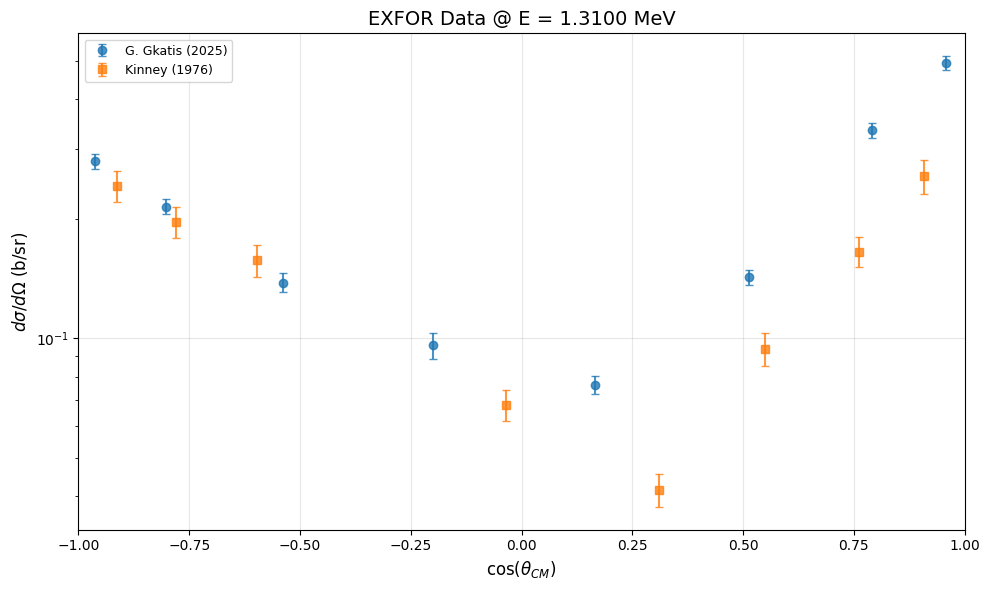

In [8]:
if exfor_df.empty:
    print("No data to plot")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Color palette for experiments
    colors = plt.cm.tab10.colors
    markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', '<', '>']
    
    # Plot each experiment with different color
    exp_ids = exfor_df['experiment_id'].unique() if 'experiment_id' in exfor_df.columns else [None]
    
    for i, exp_id in enumerate(exp_ids):
        if exp_id is not None:
            mask = exfor_df['experiment_id'] == exp_id
            df_exp = exfor_df[mask]
            # Find experiment info
            exp_info = next((e for e in experiments_info 
                           if f"{e.get('entry', '')}/{e.get('subentry', '')}" == exp_id), {})
            label = f"{exp_info.get('author', exp_id)} ({exp_info.get('year', '?')})"
        else:
            df_exp = exfor_df
            label = 'EXFOR data'
        
        ax.errorbar(
            df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
            fmt=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=label,
            capsize=3,
            markersize=6,
            alpha=0.8
        )
    
    ax.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=12)
    ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=12)
    ax.set_title(f'EXFOR Data @ E = {bin_info.energy_mev:.4f} MeV', fontsize=14)
    ax.set_xlim(-1, 1)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    plt.tight_layout()
    plt.show()

## 8. Perform Nominal Fit

Fit Legendre coefficients to the EXFOR data using the nominal (best-fit) approach.

In [9]:
if exfor_df.empty:
    print("No data available for fitting")
    nominal_coeffs = None
    fit_info = None
    degree_weights = None
else:
    print("Performing nominal Legendre fit...")
    
    # Perform nominal fit (n_samples=1)
    coef_df, fit_info = sample_legendre_coefficients(
        exfor_df,
        value_col="value",
        unc_col="unc",
        degree=None,  # Auto-select using AICc/BIC
        max_degree=MAX_LEGENDRE_DEGREE,
        select_degree=SELECT_DEGREE,
        ridge_lambda=RIDGE_LAMBDA,
        external_weights=kernel_weights,
        n_samples=1,
        use_band_discrepancy=USE_BAND_DISCREPANCY,
        min_points_per_band=MIN_POINTS_PER_BAND,
        max_tau_fraction=MAX_TAU_FRACTION,
    )
    
    # Extract nominal coefficients
    nominal_coeffs = coef_df.iloc[0].to_numpy()
    fitted_degree = fit_info['degree']
    chi2_red = fit_info['chi2_red']
    tau_info = fit_info.get('tau_info', {})
    
    # Compute degree_weights for model averaging (Improvement 2.4)
    all_degrees_info = fit_info.get('all_degrees_info', None)
    degree_weights = None
    
    if all_degrees_info and len(all_degrees_info) > 1:
        aicc_values = {d: info['aicc'] for d, info in all_degrees_info.items()}
        min_aicc = min(aicc_values.values())
        raw_weights = {d: np.exp(-0.5 * (aicc - min_aicc)) for d, aicc in aicc_values.items()}
        total = sum(raw_weights.values())
        degree_weights = {d: w / total for d, w in raw_weights.items()}
        # Filter to weights > 1% and degree >= 1 (model averaging minimum)
        MIN_DEGREE_FOR_AVERAGING = 1
        degree_weights = {d: w for d, w in degree_weights.items() if w > 0.01 and d >= MIN_DEGREE_FOR_AVERAGING}
        if degree_weights:
            total = sum(degree_weights.values())
            degree_weights = {d: w / total for d, w in degree_weights.items()}
        else:
            degree_weights = {fitted_degree: 1.0}
    
    print(f"\nFit Results:")
    print(f"  Selected degree: L = {fitted_degree}")
    print(f"  Reduced chi-squared: {chi2_red:.3f}")
    print(f"  Effective parameters: {fit_info.get('eff_params', fitted_degree + 1)}")
    
    if tau_info:
        print(f"\nBand discrepancy (tau values):")
        print(f"  tau_F (forward, mu > 0.5):  {tau_info.get('tau_F', 0):.4f}")
        print(f"  tau_M (mid, |mu| <= 0.5):   {tau_info.get('tau_M', 0):.4f}")
        print(f"  tau_B (backward, mu < -0.5): {tau_info.get('tau_B', 0):.4f}")
    
    # Show degree weights for model averaging
    if degree_weights and len(degree_weights) > 1:
        print(f"\nDegree weights for model averaging (Improvement 2.4):")
        for d, w in sorted(degree_weights.items()):
            marker = " <-- selected" if d == fitted_degree else ""
            print(f"  L={d}: {w*100:.1f}%{marker}")
        print(f"  USE_DEGREE_SAMPLING_IN_MC = {USE_DEGREE_SAMPLING_IN_MC}")
    elif degree_weights:
        print(f"\nDegree weights: Only L={fitted_degree} has significant weight (100%)")
        print(f"  (Degree sampling will be skipped)")
    
    print(f"\nFitted Legendre coefficients [c0, c1, ..., c{fitted_degree}]:")
    for i, c in enumerate(nominal_coeffs):
        print(f"  c{i} = {c:+.6f}")

Performing nominal Legendre fit...

Fit Results:
  Selected degree: L = 4
  Reduced chi-squared: 16.819
  Effective parameters: 4.999999854501519

Band discrepancy (tau values):
  tau_F (forward, mu > 0.5):  0.0527
  tau_M (mid, |mu| <= 0.5):   0.0169
  tau_B (backward, mu < -0.5): 0.0000

Degree weights for model averaging (Improvement 2.4):
  L=4: 63.6% <-- selected
  L=5: 10.4%
  L=8: 26.1%
  USE_DEGREE_SAMPLING_IN_MC = True

Fitted Legendre coefficients [c0, c1, ..., c4]:
  c0 = +0.156814
  c1 = +0.032203
  c2 = +0.205924
  c3 = +0.077551
  c4 = +0.043185


## 9. Visualize Nominal Fit vs Data

Compare the nominal fit curve with the experimental data.

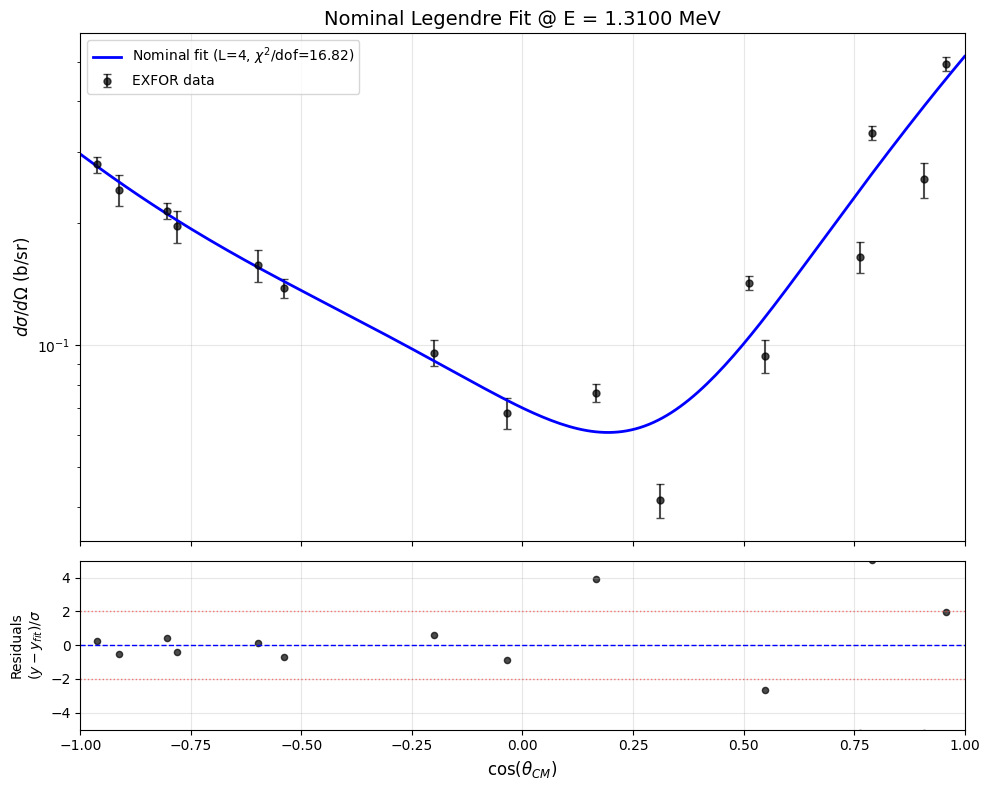


Residual statistics:
  Mean: -0.187 (should be ~0)
  Std: 3.395 (should be ~1 if chi2/dof ~1)
  Points outside +/-2 sigma: 7/16


In [10]:
if nominal_coeffs is None:
    print("No fit available")
else:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[3, 1], sharex=True)
    
    # Grid for fit curve
    mu_grid = np.linspace(-1, 1, 200)
    y_fit = legval(mu_grid, nominal_coeffs)
    
    # Plot data
    ax1.errorbar(
        exfor_df['mu'], exfor_df['value'], yerr=exfor_df['unc'],
        fmt='o', color='black', label='EXFOR data',
        capsize=3, markersize=5, alpha=0.7
    )
    
    # Plot nominal fit
    ax1.plot(mu_grid, y_fit, 'b-', linewidth=2, 
             label=f'Nominal fit (L={fit_info["degree"]}, $\\chi^2$/dof={chi2_red:.2f})')
    
    ax1.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=12)
    ax1.set_title(f'Nominal Legendre Fit @ E = {bin_info.energy_mev:.4f} MeV', fontsize=14)
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')
    
    # Residuals plot
    mu_data = exfor_df['mu'].values
    y_data = exfor_df['value'].values
    sigma_data = exfor_df['unc'].values
    y_fit_at_data = legval(mu_data, nominal_coeffs)
    residuals = (y_data - y_fit_at_data) / sigma_data
    
    ax2.scatter(mu_data, residuals, c='black', s=20, alpha=0.7)
    ax2.axhline(0, color='blue', linestyle='--', linewidth=1)
    ax2.axhline(2, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax2.axhline(-2, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax2.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=12)
    ax2.set_ylabel('Residuals\n$(y - y_{fit})/\\sigma$', fontsize=10)
    ax2.set_xlim(-1, 1)
    ax2.set_ylim(-5, 5)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Residual statistics
    print(f"\nResidual statistics:")
    print(f"  Mean: {np.mean(residuals):.3f} (should be ~0)")
    print(f"  Std: {np.std(residuals):.3f} (should be ~1 if chi2/dof ~1)")
    print(f"  Points outside +/-2 sigma: {np.sum(np.abs(residuals) > 2)}/{len(residuals)}")

## 10. Generate MC Samples

Generate Monte Carlo samples of Legendre coefficients by jittering the data.

In [11]:
if exfor_df.empty:
    print("No data available for sampling")
    all_samples = None
else:
    print(f"Generating {N_SAMPLES} MC samples...")
    
    # Choose data source for MC (two-pass dedupe - Improvement 2.3)
    mc_df = exfor_df_mc if exfor_df_mc is not None else exfor_df
    mc_weights = kernel_weights_mc if kernel_weights_mc is not None else kernel_weights
    
    if exfor_df_mc is not None:
        print(f"  Using MC-specific data (two-pass dedupe): {len(mc_df)} points")
    else:
        print(f"  Using same data as nominal fit: {len(mc_df)} points")
    
    # Check if degree sampling is enabled (Improvement 2.4)
    use_degree_sampling = (
        USE_DEGREE_SAMPLING_IN_MC and
        degree_weights is not None and
        len(degree_weights) > 1
    )
    
    if use_degree_sampling:
        print(f"  Degree sampling: ENABLED (sampling from {len(degree_weights)} degrees)")
        
        # Per-sample fitting with degree sampling
        degrees = list(degree_weights.keys())
        probs = np.array(list(degree_weights.values()))
        probs = probs / probs.sum()
        
        rng = np.random.default_rng(BASE_SEED)
        all_samples_list = []
        degree_used = []
        
        for s_idx in range(N_SAMPLES):
            sample_degree = rng.choice(degrees, p=probs)
            degree_used.append(sample_degree)
            
            # FIX: Use n_samples=2 to trigger the MC jittering loop
            # When n_samples=1, sample_legendre_coefficients just returns the nominal fit
            # without applying normalization noise (sigma_norm) or pointwise jitter.
            # With n_samples=2, both samples are properly jittered.
            coef_df_single, _ = sample_legendre_coefficients(
                mc_df,
                value_col="value",
                unc_col="unc",
                degree=sample_degree,
                max_degree=MAX_LEGENDRE_DEGREE,
                select_degree=None,
                ridge_lambda=RIDGE_LAMBDA,
                external_weights=mc_weights,
                n_samples=2,  # FIX: Generate 2 samples to trigger jittering loop
                random_state=BASE_SEED + s_idx,
                use_band_discrepancy=USE_BAND_DISCREPANCY,
                min_points_per_band=MIN_POINTS_PER_BAND,
                max_tau_fraction=MAX_TAU_FRACTION,
                freeze_c0=FREEZE_C0,
                fixed_c0_value=nominal_coeffs[0],  # FIX: Use nominal c0, not FIXED_C0_VALUE (which is None)
                sigma_norm=NORMALIZATION_SIGMA,
                norm_dist=NORM_DIST,
            )
            # Take the first jittered sample (when n_samples>1, all samples are jittered)
            sample_coeffs = coef_df_single.iloc[0].to_numpy()
            # Pad to max_degree+1 if needed
            if len(sample_coeffs) < MAX_LEGENDRE_DEGREE + 1:
                sample_coeffs = np.pad(sample_coeffs, (0, MAX_LEGENDRE_DEGREE + 1 - len(sample_coeffs)))
            all_samples_list.append(sample_coeffs)
        
        all_samples = np.array(all_samples_list)
        
        # Report degree usage
        from collections import Counter
        degree_counts = Counter(degree_used)
        print(f"\n  Degrees sampled:")
        for d, count in sorted(degree_counts.items()):
            expected = probs[degrees.index(d)] * N_SAMPLES
            print(f"    L={d}: {count}/{N_SAMPLES} ({count/N_SAMPLES*100:.0f}%, expected {expected:.0f})")
    
    else:
        # Current batch MC behavior (frozen degree)
        if degree_weights is not None and len(degree_weights) == 1:
            print(f"  Degree sampling: SKIPPED (only one degree has weight)")
        else:
            print(f"  Degree sampling: DISABLED (USE_DEGREE_SAMPLING_IN_MC={USE_DEGREE_SAMPLING_IN_MC})")
        print(f"  Using frozen degree: L={fit_info['degree']}")
        
        # Generate samples with all new parameters
        samples_df, samples_info = sample_legendre_coefficients(
            mc_df,
            value_col="value",
            unc_col="unc",
            degree=fit_info['degree'],  # Use frozen degree from nominal fit
            max_degree=MAX_LEGENDRE_DEGREE,
            ridge_lambda=RIDGE_LAMBDA,
            external_weights=mc_weights,
            n_samples=N_SAMPLES,
            random_state=BASE_SEED,  # Use seed for reproducibility
            use_band_discrepancy=USE_BAND_DISCREPANCY,
            min_points_per_band=MIN_POINTS_PER_BAND,
            max_tau_fraction=MAX_TAU_FRACTION,
            # Fixed-c0 mode (Improvement 1.2)
            freeze_c0=FREEZE_C0,
            fixed_c0_value=FIXED_C0_VALUE,
            # Correlated normalization uncertainty (Improvement 1.3)
            sigma_norm=NORMALIZATION_SIGMA,
            norm_dist=NORM_DIST,
        )
        
        # Convert to numpy array
        all_samples = samples_df.to_numpy()  # Shape: (N_SAMPLES, n_coeffs)
    
    # Compute MC statistics
    mc_mean = np.mean(all_samples, axis=0)
    mc_std = np.std(all_samples, axis=0)
    
    # Truncate to the maximum degree used (for display)
    max_used_degree = max(len(c) for c in all_samples) if use_degree_sampling else fit_info['degree'] + 1
    
    print(f"\nMC Sample Statistics (max L={max_used_degree - 1}):")
    print(f"{'Coeff':<6} {'Nominal':>12} {'MC Mean':>12} {'MC Std':>12} {'Unc %':>10}")
    print("-" * 56)
    for i in range(min(len(mc_mean), len(nominal_coeffs))):
        unc_pct = 100 * mc_std[i] / abs(mc_mean[i]) if mc_mean[i] != 0 else 0.0
        print(f"c{i:<5} {nominal_coeffs[i] if i < len(nominal_coeffs) else 0.0:>+12.6f} {mc_mean[i]:>+12.6f} {mc_std[i]:>12.6f} {unc_pct:>9.1f}%")
    
    # Show additional info from sampling
    print(f"\nSampling parameters used:")
    print(f"  random_state (seed): {BASE_SEED}")
    print(f"  freeze_c0: {FREEZE_C0}")
    if FREEZE_C0:
        print(f"  fixed_c0_value: {nominal_coeffs[0]:.6f}")
    print(f"  sigma_norm: {NORMALIZATION_SIGMA*100:.1f}%")
    print(f"  degree_sampling: {use_degree_sampling}")

Generating 25 MC samples...
  Using same data as nominal fit: 16 points
  Degree sampling: ENABLED (sampling from 3 degrees)

  Degrees sampled:
    L=4: 11/25 (44%, expected 16)
    L=5: 2/25 (8%, expected 3)
    L=8: 12/25 (48%, expected 7)

MC Sample Statistics (max L=8):
Coeff       Nominal      MC Mean       MC Std      Unc %
--------------------------------------------------------
c0        +0.156814    +0.156814     0.000000       0.0%
c1        +0.032203    +0.036047     0.010433      28.9%
c2        +0.205924    +0.207658     0.014329       6.9%
c3        +0.077551    +0.074844     0.023657      31.6%
c4        +0.043185    +0.052914     0.020691      39.1%

Sampling parameters used:
  random_state (seed): 42
  freeze_c0: True
  fixed_c0_value: 0.156814
  sigma_norm: 5.0%
  degree_sampling: True


## 11. Compare with Original ENDF

Convert fitted coefficients to ENDF format and compare with the original evaluation.

In [12]:
if nominal_coeffs is None:
    print("No fit available")
else:
    # Convert fitted coefficients to ENDF format
    # ENDF: a_l = (c_l / c_0) / (2l+1) for l>=1, a_0 = 1
    fitted_endf_coeffs = endf_normalize_legendre_coeffs(nominal_coeffs, include_a0=True)
    mc_mean_endf_coeffs = endf_normalize_legendre_coeffs(mc_mean, include_a0=True)
    
    # Compute MC standard deviation in ENDF format (sqrt of MF34 variance)
    # Convert each MC sample to ENDF format, then compute std
    mc_samples_endf = np.array([
        endf_normalize_legendre_coeffs(all_samples[i], include_a0=True)
        for i in range(len(all_samples))
    ])
    mc_std_endf = np.std(mc_samples_endf, axis=0)
    
    print(f"Coefficient Comparison (ENDF format, a_l):")
    print(f"{'Order':<6} {'Original ENDF':>14} {'Nominal Fit':>14} {'MC Mean':>14} {'MC Std':>12} {'Unc (%)':>10}")
    print("-" * 72)
    
    # a0 is always 1 by convention (no uncertainty)
    print(f"{'a0':<6} {'1.000000':>14} {'1.000000':>14} {'1.000000':>14} {'0.000000':>12} {'0.0':>10}")
    
    # Compare higher orders
    max_order = max(len(original_endf_coeffs), len(fitted_endf_coeffs) - 1)
    for l in range(1, max_order + 1):
        orig_val = original_endf_coeffs[l-1] if l <= len(original_endf_coeffs) else 0.0
        fit_val = fitted_endf_coeffs[l] if l < len(fitted_endf_coeffs) else 0.0
        mc_val = mc_mean_endf_coeffs[l] if l < len(mc_mean_endf_coeffs) else 0.0
        mc_std_val = mc_std_endf[l] if l < len(mc_std_endf) else 0.0
        # Relative uncertainty in %
        rel_unc = 100.0 * mc_std_val / abs(mc_val) if abs(mc_val) > 1e-10 else 0.0
        print(f"a{l:<5} {orig_val:>+14.6f} {fit_val:>+14.6f} {mc_val:>+14.6f} {mc_std_val:>12.6f} {rel_unc:>9.1f}%")
    
    print(f"\nNote: 'MC Std' = sqrt(variance) of a_l from MC samples (MF34 diagonal).")
    print(f"      'Unc (%)' = relative uncertainty = 100 * MC Std / |MC Mean|")

Coefficient Comparison (ENDF format, a_l):
Order   Original ENDF    Nominal Fit        MC Mean       MC Std    Unc (%)
------------------------------------------------------------------------
a0           1.000000       1.000000       1.000000     0.000000        0.0
a1          -0.099923      +0.068453      +0.076624     0.022177      28.9%
a2          +0.224521      +0.262635      +0.264847     0.018275       6.9%
a3          +0.057129      +0.070649      +0.068183     0.021552      31.6%
a4          +0.015897      +0.030599      +0.037492     0.014661      39.1%
a5          -0.013064      +0.000000      +0.004446     0.007264     163.4%
a6          +0.004601      +0.000000      +0.003567     0.008687     243.6%

Note: 'MC Std' = sqrt(variance) of a_l from MC samples (MF34 diagonal).
      'Unc (%)' = relative uncertainty = 100 * MC Std / |MC Mean|


## 12. Energy Folding and Main Visualization Setup

**Energy Folding with TOF Resolution**

This section uses the unified `kika.utils.energy_folding` module to account for TOF energy resolution effects.

**Folding Modes:**
- `"xs_only"` (default): Folds cross section only, uses unfolded angular shape from ACE
- `"angular_only"`: Folds angular distribution only, uses unfolded cross section
- `"both"`: Folds both cross section and angular distribution

The differential cross section is computed as:
$$\frac{d\sigma}{d\Omega}(\mu, E_0) = \sigma_{folded}(E_0) \times \frac{f(\mu)}{2\pi}$$

where $\sigma_{folded}$ is the Gaussian-weighted average of $\sigma(E)$ over the energy resolution window.

In [13]:
# =============================================================================
# ENERGY FOLDING CONFIGURATION
# =============================================================================
# Using the new unified energy folding module from kika.utils.energy_folding
#
# Folding modes:
#   - "xs_only" (default): Fold cross section only, use ENDF angular shape
#   - "angular_only": Fold angular distribution only, use unfolded XS
#   - "both": Fold both cross section and angular distribution
#
# Angular distributions: Always use ENDF Legendre coefficients
# Cross sections: Use ACE data (since ENDF XS parsing not available)

FOLDING_MODE = "xs_only"  # Options: "xs_only", "angular_only", "both"

# Create energy folding configuration with TOF parameters
folding_config = EnergyFoldingConfig(
    flight_path_m=FLIGHT_PATH_M,
    delta_t_ns=DELTA_T_NS,
    n_sigma=2.0,
    n_samples=21,
)

# Test: the integral of f(mu) from -1 to 1 should be 1
mu_test = np.linspace(-1, 1, 1000)
f_test = endf_angular_distribution(mu_test, original_endf_coeffs)
integral = np.trapezoid(f_test, mu_test)
print(f"Test: integral of ENDF angular dist = {integral:.6f} (should be ~1.0)")

# =============================================================================
# LOAD ACE DATA AND COMPUTE FOLDED CROSS SECTIONS
# =============================================================================
print(f"\nLoading ACE data for cross section folding...")
print(f"Folding mode: {FOLDING_MODE}")

ace_data = kika.read_ace(ACE_FILE_PATH)

# Compute folded cross section using the library function
folded_xs, original_xs = fold_cross_section(
    ace_data=ace_data,
    target_energy_mev=bin_info.energy_mev,
    mt=MT_NUMBER,
    sigma_E_mev=bin_info.sigma_E_mev,
    n_sigma=folding_config.n_sigma,
)

print(f"ACE data loaded successfully")
print(f"Energy resolution for folding: sigma_E = {bin_info.sigma_E_mev*1000:.2f} keV")
print(f"Original cross section at {bin_info.energy_mev:.4f} MeV: {original_xs:.4f} b")
print(f"Energy-folded cross section: {folded_xs:.4f} b")
print(f"Folding factor (folded/original): {folded_xs/original_xs:.4f}")

# =============================================================================
# COMPUTE DIFFERENTIAL CROSS SECTIONS
# Using ENDF Legendre coefficients for angular distributions
# =============================================================================

# Compute folded differential cross section
# Uses ENDF angular distribution + folded XS from ACE
mu_folded, dsigma_folded, folding_info = compute_folded_differential_xs(
    ace_data=ace_data,
    target_energy_mev=bin_info.energy_mev,
    mt=MT_NUMBER,
    config=folding_config,
    mode=FOLDING_MODE,
    endf_coeffs=np.array(original_endf_coeffs),  # Use ENDF angular distribution
)

# Compute unfolded differential cross section
# Uses ENDF angular distribution + unfolded XS from ACE
mu_unfolded, dsigma_unfolded, unfolded_info = compute_unfolded_differential_xs(
    ace_data=ace_data,
    target_energy_mev=bin_info.energy_mev,
    mt=MT_NUMBER,
    endf_coeffs=np.array(original_endf_coeffs),  # Use ENDF angular distribution
)

print(f"\nFolding info:")
print(f"  Mode: {folding_info['mode']}")
print(f"  σ_E: {folding_info['sigma_E_kev']:.2f} keV")
print(f"  XS ratio (folded/unfolded): {folding_info['xs_ratio']:.4f}")

# =============================================================================
# VERIFY: In xs_only mode, the ratio should be constant
# =============================================================================
ratio = dsigma_folded / dsigma_unfolded
print(f"\nVerification (xs_only mode):")
print(f"  Ratio dsigma_folded / dsigma_unfolded:")
print(f"    min = {ratio.min():.6f}")
print(f"    max = {ratio.max():.6f}")
print(f"    Expected (XS ratio) = {folding_info['xs_ratio']:.6f}")
print(f"  Ratio is constant: {np.allclose(ratio, folding_info['xs_ratio'], rtol=1e-6)}")

Test: integral of ENDF angular dist = 1.000002 (should be ~1.0)

Loading ACE data for cross section folding...
Folding mode: xs_only
ACE data loaded successfully
Energy resolution for folding: sigma_E = 7.67 keV
Original cross section at 1.3100 MeV: 1.0102 b
Energy-folded cross section: 1.9243 b
Folding factor (folded/original): 1.9049

Folding info:
  Mode: xs_only
  σ_E: 3.26 keV
  XS ratio (folded/unfolded): 1.3200

Verification (xs_only mode):
  Ratio dsigma_folded / dsigma_unfolded:
    min = 1.319988
    max = 1.319988
    Expected (XS ratio) = 1.319988
  Ratio is constant: True


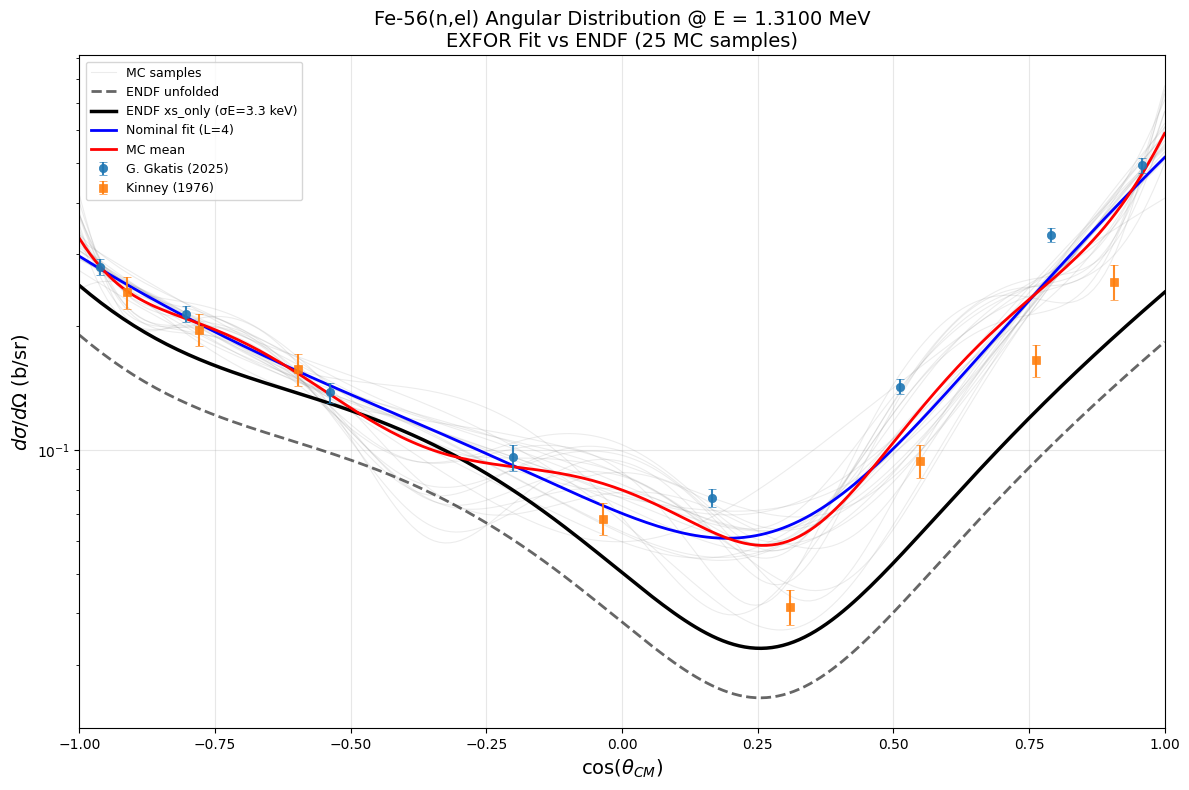

In [14]:
if nominal_coeffs is None:
    print("No fit available")
else:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Grid for curves
    mu_grid = np.linspace(-1, 1, 200)
    
    # Color palette and markers for experiments
    colors = plt.cm.tab10.colors
    markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', '<', '>']
    
    # 1. Plot MC samples (first, so they're in background)
    if all_samples is not None:
        for i in range(min(N_SAMPLES, 25)):
            y_sample = legval(mu_grid, all_samples[i])
            label = 'MC samples' if i == 0 else None
            ax.plot(mu_grid, y_sample, '-', color='gray', alpha=0.15, linewidth=0.8, label=label)
    
    # 2. Unfolded (original ENDF shape + unfolded XS)
    ax.plot(mu_unfolded, dsigma_unfolded, 'k--', linewidth=2, alpha=0.6, 
            label='ENDF unfolded')
    
    # 3. Folded (ENDF shape + folded XS)
    ax.plot(mu_folded, dsigma_folded, 'k-', linewidth=2.5, 
            label=f'ENDF {FOLDING_MODE} (σE={folding_info["sigma_E_kev"]:.1f} keV)')
    
    # 4. Nominal fit
    y_nominal = legval(mu_grid, nominal_coeffs)
    ax.plot(mu_grid, y_nominal, 'b-', linewidth=2, 
            label=f'Nominal fit (L={fit_info["degree"]})')
    
    # 5. MC mean fit
    if all_samples is not None:
        y_mc_mean = legval(mu_grid, mc_mean)
        ax.plot(mu_grid, y_mc_mean, 'r-', linewidth=2, label='MC mean')
    
    # 6. EXFOR data points - different color per experiment
    exp_ids = exfor_df['experiment_id'].unique() if 'experiment_id' in exfor_df.columns else [None]
    
    for i, exp_id in enumerate(exp_ids):
        if exp_id is not None:
            mask = exfor_df['experiment_id'] == exp_id
            df_exp = exfor_df[mask]
            exp_info = next((e for e in experiments_info 
                           if f"{e.get('entry', '')}/{e.get('subentry', '')}" == exp_id), {})
            label = f"{exp_info.get('author', exp_id)} ({exp_info.get('year', '?')})"
        else:
            df_exp = exfor_df
            label = 'EXFOR data'
        
        ax.errorbar(
            df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
            fmt=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=label,
            capsize=3,
            markersize=6,
            alpha=0.9,
            markeredgewidth=0.5
        )
    
    # Formatting
    ax.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=14)
    ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=14)
    ax.set_title(
        f'Fe-56(n,el) Angular Distribution @ E = {bin_info.energy_mev:.4f} MeV\n'
        f'EXFOR Fit vs ENDF ({N_SAMPLES} MC samples)',
        fontsize=14
    )
    ax.set_xlim(-1, 1)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    plt.tight_layout()
    plt.show()

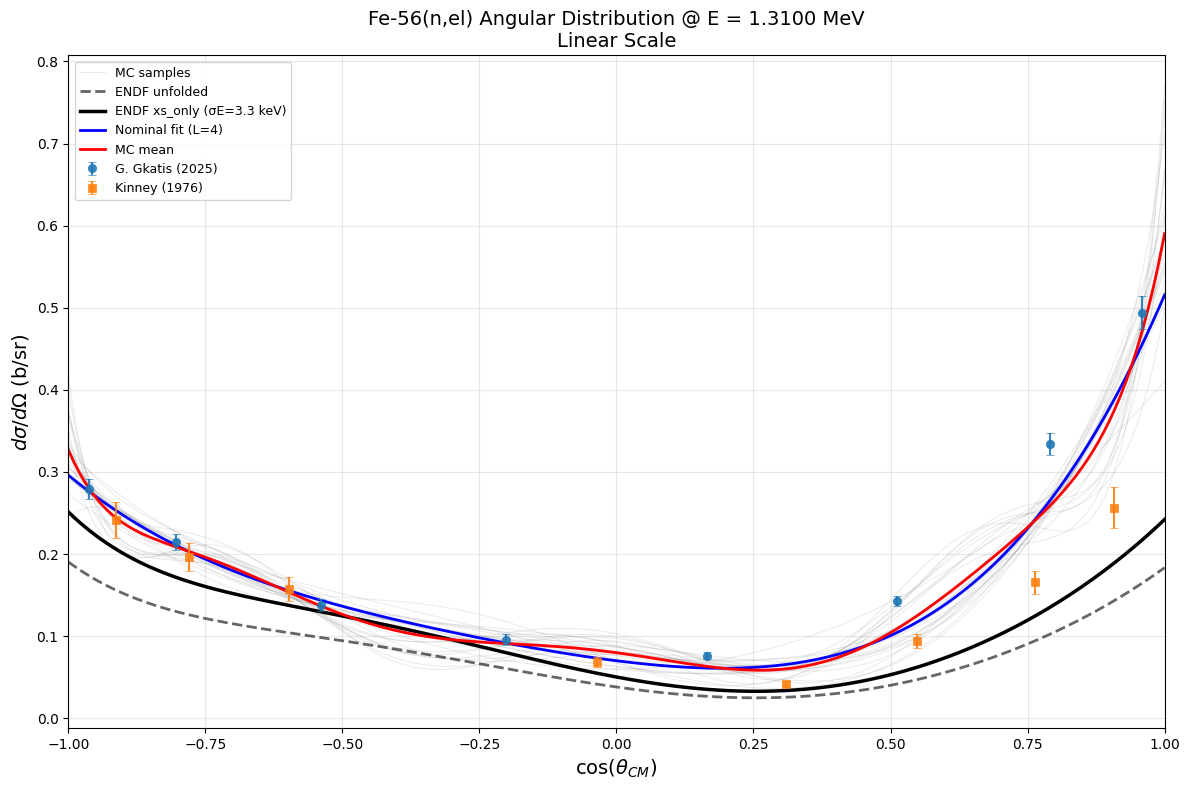

In [15]:
# Same plot with LINEAR scale
if nominal_coeffs is not None:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    mu_grid = np.linspace(-1, 1, 200)
    
    # Color palette and markers for experiments
    colors = plt.cm.tab10.colors
    markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', '<', '>']
    
    # MC samples
    if all_samples is not None:
        for i in range(min(N_SAMPLES, 25)):
            y_sample = legval(mu_grid, all_samples[i])
            label = 'MC samples' if i == 0 else None
            ax.plot(mu_grid, y_sample, '-', color='gray', alpha=0.15, linewidth=0.8, label=label)
    
    # Unfolded (ENDF shape + unfolded XS)
    ax.plot(mu_unfolded, dsigma_unfolded, 'k--', linewidth=2, alpha=0.6, 
            label='ENDF unfolded')
    
    # Folded (ENDF shape + folded XS)
    ax.plot(mu_folded, dsigma_folded, 'k-', linewidth=2.5, 
            label=f'ENDF {FOLDING_MODE} (σE={folding_info["sigma_E_kev"]:.1f} keV)')
    
    # Nominal fit
    y_nominal = legval(mu_grid, nominal_coeffs)
    ax.plot(mu_grid, y_nominal, 'b-', linewidth=2, 
            label=f'Nominal fit (L={fit_info["degree"]})')
    
    # MC mean
    if all_samples is not None:
        y_mc_mean = legval(mu_grid, mc_mean)
        ax.plot(mu_grid, y_mc_mean, 'r-', linewidth=2, label='MC mean')
    
    # EXFOR data - different color per experiment
    exp_ids = exfor_df['experiment_id'].unique() if 'experiment_id' in exfor_df.columns else [None]
    
    for i, exp_id in enumerate(exp_ids):
        if exp_id is not None:
            mask = exfor_df['experiment_id'] == exp_id
            df_exp = exfor_df[mask]
            exp_info = next((e for e in experiments_info 
                           if f"{e.get('entry', '')}/{e.get('subentry', '')}" == exp_id), {})
            label = f"{exp_info.get('author', exp_id)} ({exp_info.get('year', '?')})"
        else:
            df_exp = exfor_df
            label = 'EXFOR data'
        
        ax.errorbar(
            df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
            fmt=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=label,
            capsize=3,
            markersize=6,
            alpha=0.9,
            markeredgewidth=0.5
        )
    
    ax.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=14)
    ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=14)
    ax.set_title(
        f'Fe-56(n,el) Angular Distribution @ E = {bin_info.energy_mev:.4f} MeV\n'
        f'Linear Scale',
        fontsize=14
    )
    ax.set_xlim(-1, 1)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 13. Coefficient Comparison Plot

Visualize the differences in Legendre coefficients between methods.

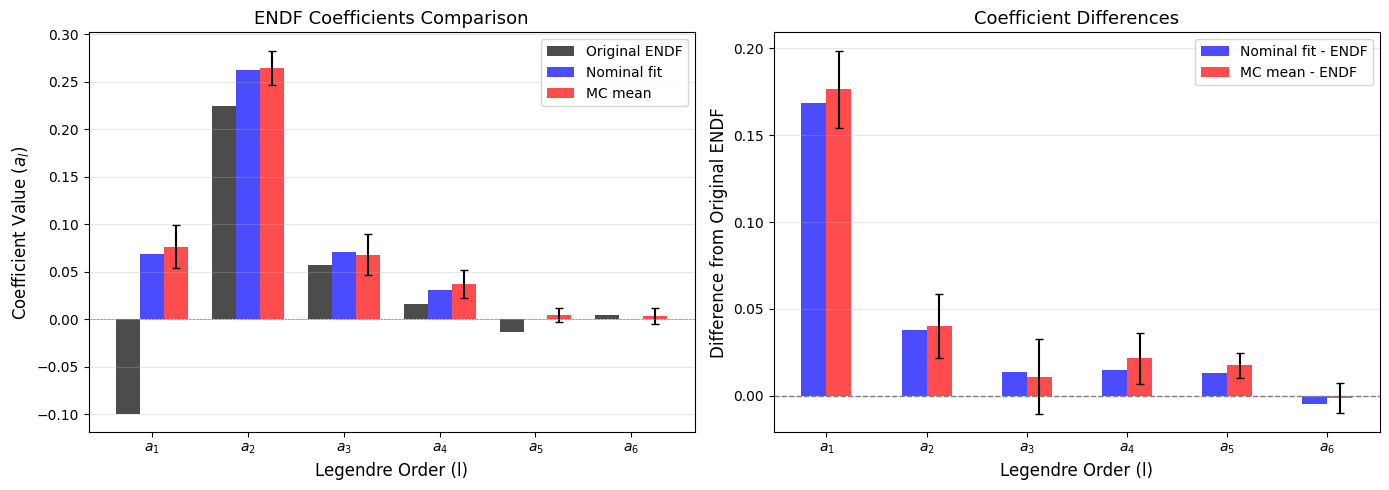

In [16]:
if nominal_coeffs is None:
    print("No fit available")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Convert to ENDF format for comparison
    fitted_a = endf_normalize_legendre_coeffs(nominal_coeffs, include_a0=True)
    mc_mean_a = endf_normalize_legendre_coeffs(mc_mean, include_a0=True)

    # Note on uncertainty transformation:
    # When c0 is fixed (FREEZE_C0=True), mc_std[0]=0, so we cannot use
    # endf_normalize_legendre_coeffs on the std vector directly (causes division by zero).
    # Instead, use mc_std_endf which was correctly computed in Cell 23 by transforming
    # each MC sample to ENDF format first, then computing std.
    #
    # Key insight: Relative uncertainties (std/|mean|) are the SAME for c and a coefficients
    # when c0 is fixed, because the scaling factor cancels:
    #   a_l = c_l / (c0 * (2l+1))  =>  std(a_l)/|a_l| = std(c_l)/|c_l|
    # But ABSOLUTE uncertainties differ: std(a_l) = std(c_l) / (c0 * (2l+1))
    mc_std_a = mc_std_endf  # Correct: already computed in Cell 23
    
    # Prepare data for plotting
    max_order = max(len(original_endf_coeffs), len(fitted_a) - 1)
    orders = np.arange(1, max_order + 1)
    
    orig_vals = np.array([original_endf_coeffs[l-1] if l <= len(original_endf_coeffs) else 0.0 
                         for l in orders])
    fit_vals = np.array([fitted_a[l] if l < len(fitted_a) else 0.0 for l in orders])
    mc_vals = np.array([mc_mean_a[l] if l < len(mc_mean_a) else 0.0 for l in orders])
    mc_errs = np.array([abs(mc_std_a[l]) if l < len(mc_std_a) else 0.0 for l in orders])
    
    # Left plot: Coefficient values
    width = 0.25
    x = np.arange(len(orders))
    
    ax1.bar(x - width, orig_vals, width, label='Original ENDF', color='black', alpha=0.7)
    ax1.bar(x, fit_vals, width, label='Nominal fit', color='blue', alpha=0.7)
    ax1.bar(x + width, mc_vals, width, label='MC mean', color='red', alpha=0.7, 
           yerr=mc_errs, capsize=3)
    
    ax1.set_xlabel('Legendre Order (l)', fontsize=12)
    ax1.set_ylabel('Coefficient Value ($a_l$)', fontsize=12)
    ax1.set_title('ENDF Coefficients Comparison', fontsize=13)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'$a_{l}$' for l in orders])
    ax1.legend(fontsize=10)
    ax1.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Right plot: Differences from original ENDF
    diff_fit = fit_vals - orig_vals
    diff_mc = mc_vals - orig_vals
    
    ax2.bar(x - width/2, diff_fit, width, label='Nominal fit - ENDF', color='blue', alpha=0.7)
    ax2.bar(x + width/2, diff_mc, width, label='MC mean - ENDF', color='red', alpha=0.7,
           yerr=mc_errs, capsize=3)
    
    ax2.set_xlabel('Legendre Order (l)', fontsize=12)
    ax2.set_ylabel('Difference from Original ENDF', fontsize=12)
    ax2.set_title('Coefficient Differences', fontsize=13)
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'$a_{l}$' for l in orders])
    ax2.legend(fontsize=10)
    ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

## 14. Summary Statistics

In [17]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nEnergy: {bin_info.energy_mev:.6f} MeV")
print(f"Energy bin: [{bin_info.bin_lower_mev:.6f}, {bin_info.bin_upper_mev:.6f}] MeV")
print(f"Method: {EXPERIMENT_SELECTION_METHOD}")

print(f"\nData:")
print(f"  Experiments: {len(experiments_info)}")
print(f"  Total points: {len(exfor_df)}")
if diagnostics:
    print(f"  N_eff: {diagnostics.n_eff:.1f}")
    if diagnostics.capping_applied:
        print(f"  Weight capping: Applied")

if fit_info:
    print(f"\nFit:")
    print(f"  Legendre degree: {fit_info['degree']}")
    print(f"  chi2/dof: {fit_info['chi2_red']:.3f}")
    tau = fit_info.get('tau_info', {})
    if tau:
        print(f"  tau_F: {tau.get('tau_F', 0):.4f}")
        print(f"  tau_M: {tau.get('tau_M', 0):.4f}")
        print(f"  tau_B: {tau.get('tau_B', 0):.4f}")

if all_samples is not None:
    print(f"\nMC Sampling:")
    print(f"  N_samples: {N_SAMPLES}")
    print(f"  Coefficient spread (c0): {mc_std[0]:.6f}")
    if 'use_degree_sampling' in dir() and use_degree_sampling:
        print(f"  Degree sampling: ENABLED")
    
print(f"\nEnergy Bin Method Parameters (Improvements 1.1-1.3):")
print(f"  normalize_by_n_points: {NORMALIZE_BY_N_POINTS}")
print(f"  max_exp_weight_frac: {MAX_EXP_WEIGHT_FRAC_BIN}")
print(f"  freeze_c0: {FREEZE_C0}")
print(f"  sigma_norm: {NORMALIZATION_SIGMA*100:.1f}%")
print(f"  norm_dist: {NORM_DIST}")

print(f"\nKernel Weights Method Parameters (Improvements 2.1-2.4):")
print(f"  use_overlap_weights: {USE_OVERLAP_WEIGHTS}")
print(f"  normalize_by_n_points: {KERNEL_NORMALIZE_BY_N_POINTS}")
print(f"  dedupe_nominal: {DEDUPE_NOMINAL}")
print(f"  dedupe_mc: {DEDUPE_MC}")
print(f"  use_degree_sampling: {USE_DEGREE_SAMPLING_IN_MC}")

if exfor_df_mc is not None:
    print(f"\n  Two-pass dedupe active:")
    print(f"    Nominal data points: {len(exfor_df)}")
    print(f"    MC data points: {len(exfor_df_mc)}")

print("\n" + "=" * 60)

SUMMARY

Energy: 1.310000 MeV
Energy bin: [1.309500, 1.310500] MeV
Method: energy_bin

Data:
  Experiments: 2
  Total points: 16
  N_eff: 16.0

Fit:
  Legendre degree: 4
  chi2/dof: 16.819
  tau_F: 0.0527
  tau_M: 0.0169
  tau_B: 0.0000

MC Sampling:
  N_samples: 25
  Coefficient spread (c0): 0.000000
  Degree sampling: ENABLED

Energy Bin Method Parameters (Improvements 1.1-1.3):
  normalize_by_n_points: True
  max_exp_weight_frac: 0.5
  freeze_c0: True
  sigma_norm: 5.0%
  norm_dist: lognormal

Kernel Weights Method Parameters (Improvements 2.1-2.4):
  use_overlap_weights: True
  normalize_by_n_points: True
  dedupe_nominal: True
  dedupe_mc: False
  use_degree_sampling: True



## 15. TOF Parameter Diagnostics (Energy Resolution)

This section shows the experiment-specific TOF parameters and computed energy resolutions.
This information is useful for understanding the energy resolution affecting your data,
even though the energy jitter feature (Improvement 1.4) is not applicable for single-bin analysis.

**Note:** Energy jitter is designed for creating cross-bin correlations in MC sampling.
Since this notebook analyzes only one energy bin, jitter is not applicable here.

In [18]:
# =============================================================================
# TOF PARAMETER DIAGNOSTICS
# =============================================================================
# This section shows the experiment-specific energy resolution (σE) for 
# experiments contributing to this bin. While the energy jitter feature
# (Improvement 1.4) is only applicable when analyzing multiple bins,
# understanding the energy resolution is still useful.

# TOF parameters file (same as used in the full pipeline)
TOF_PARAMETERS_FILE = "/share_snc/snc/JuanMonleon/EXFOR/exfor_tof_parameters.json"

try:
    from scripts.tof_parameters import (
        load_tof_parameters_file,
        get_tof_parameters,
        compute_sigma_E,
        TOFParameters,
    )
    
    # Try to load experiment-specific TOF parameters
    try:
        tof_params_cache = load_tof_parameters_file(TOF_PARAMETERS_FILE)
        print(f"Loaded TOF parameters for {len(tof_params_cache)} experiments from file")
    except FileNotFoundError:
        tof_params_cache = {}
        print(f"TOF parameters file not found: {TOF_PARAMETERS_FILE}")
        print("Using default TOF parameters for all experiments")
    
    print(f"\n{'='*70}")
    print("EXPERIMENT ENERGY RESOLUTION DIAGNOSTICS")
    print(f"{'='*70}")
    print(f"\nDefault TOF parameters (fallback):")
    print(f"  Flight path: {FLIGHT_PATH_M} m")
    print(f"  Time resolution: {DELTA_T_NS} ns")
    
    print(f"\nPer-experiment σE at E = {bin_info.energy_mev:.4f} MeV:")
    print(f"{'Experiment':<20} {'Author':<15} {'E_exfor (MeV)':<14} {'σE (keV)':<10} {'Source':<10}")
    print("-" * 70)
    
    for exp in experiments_info:
        entry = exp.get('entry', '')
        subentry = exp.get('subentry', '')
        author = exp.get('author', 'Unknown')[:14]
        e_exfor = exp.get('exfor_energy_mev', bin_info.energy_mev)
        
        # Get TOF parameters for this experiment
        subentry_key = f"{entry}{subentry}"
        tof_params = get_tof_parameters(
            subentry=subentry_key,
            tof_params_cache=tof_params_cache,
            default_flight_path_m=FLIGHT_PATH_M,
            default_time_resolution_ns=DELTA_T_NS,
        )
        
        # Compute σE at this experiment's energy
        sigma_E = compute_sigma_E(e_exfor, tof_params)
        
        exp_id = f"{entry}/{subentry}"
        print(f"{exp_id:<20} {author:<15} {e_exfor:<14.4f} {sigma_E*1000:<10.2f} {tof_params.source:<10}")
    
    print("-" * 70)
    
    # Compare with bin width
    bin_width_kev = (bin_info.bin_upper_mev - bin_info.bin_lower_mev) * 1000
    print(f"\nBin width: {bin_width_kev:.2f} keV")
    print(f"σE from default TOF: {bin_info.sigma_E_mev*1000:.2f} keV")
    
    if bin_info.sigma_E_mev > (bin_info.bin_upper_mev - bin_info.bin_lower_mev):
        print("\n⚠️  σE > bin width: Energy resolution is broader than bin boundaries")
        print("   In a multi-bin analysis, datasets would likely jump between bins")
    else:
        print("\n✓  σE < bin width: Energy resolution is narrower than bin boundaries")
        print("   In a multi-bin analysis, most datasets would stay in their nominal bin")

except ImportError as e:
    print(f"Could not import tof_parameters module: {e}")
    print("This diagnostic is optional and requires the scripts.tof_parameters module.")

Loaded TOF parameters for 10 experiments from file

EXPERIMENT ENERGY RESOLUTION DIAGNOSTICS

Default TOF parameters (fallback):
  Flight path: 27.037 m
  Time resolution: 5.0 ns

Per-experiment σE at E = 1.3100 MeV:
Experiment           Author          E_exfor (MeV)  σE (keV)   Source    
----------------------------------------------------------------------
27673/27673002       G. Gkatis       1.3099         7.67       default   
10571/002            Kinney          1.3100         8.30       file      
----------------------------------------------------------------------

Bin width: 1.00 keV
σE from default TOF: 7.67 keV

⚠️  σE > bin width: Energy resolution is broader than bin boundaries
   In a multi-bin analysis, datasets would likely jump between bins


## 16. Next Steps

1. **Change TARGET_ENERGY_MEV** at the top to explore different energies
2. **Try different methods**: Change `EXPERIMENT_SELECTION_METHOD` to `"kernel_weights"`
3. **Adjust fitting parameters**: Modify `MAX_LEGENDRE_DEGREE`, `SELECT_DEGREE`, etc.
4. **Increase samples**: Change `N_SAMPLES` for better uncertainty estimates

### Energy Bin Method Parameters (Improvements 1.1-1.3)

5. **Per-experiment weighting (1.1)**:
   - Set `NORMALIZE_BY_N_POINTS = True` to give equal weight per experiment
   - Set `MAX_EXP_WEIGHT_FRAC_BIN < 1.0` to cap dominant experiments

6. **Fixed-c0 mode (1.2)**:
   - Set `FREEZE_C0 = True` for shape-only refits (MF3 fixed, MF34 explains discrepancies)
   - Optionally set `FIXED_C0_VALUE` to use a specific c0 value

7. **Correlated normalization (1.3)**:
   - Adjust `NORMALIZATION_SIGMA` (e.g., 0.05 for 5% normalization uncertainty)
   - Choose `NORM_DIST`: "lognormal" (default, always positive) or "normal"

### Kernel Weights Method Parameters (Improvements 2.1-2.4)

8. **Recommended kernel settings (2.1)**:
   - Set `USE_OVERLAP_WEIGHTS = True` for better experiment balancing
   - Set `KERNEL_NORMALIZE_BY_N_POINTS = True` for equal weight per experiment

9. **Two-pass dedupe (2.3)**:
   - Set `DEDUPE_NOMINAL = True` for stable nominal fits (one energy per experiment)
   - Set `DEDUPE_MC = False` to enable energy correlations in MC sampling
   - When `DEDUPE_MC != DEDUPE_NOMINAL`, two filter passes are performed:
     - Nominal pass: used for fitting (deduped data)
     - MC pass: used for MC sampling (may include multiple energies per experiment)

10. **Degree sampling in MC (2.4)**:
    - Set `USE_DEGREE_SAMPLING_IN_MC = True` to sample degree from AICc-based weights
    - This increases uncertainty when multiple degrees are AICc-close
    - Provides model averaging over polynomial orders

### Energy Jitter for Cross-Bin Correlation (Improvement 1.4)

**Note:** Energy jitter is **not applicable** in this single-energy notebook because it requires 
multiple energy bins to create cross-bin correlations. To see energy jitter in action, run the 
full `exfor_to_endf_sampling_v2.py` script with:

```python
USE_ENERGY_JITTER = True
TOF_PARAMETERS_FILE = "/share_snc/snc/JuanMonleon/EXFOR/exfor_tof_parameters.json"
JITTER_N_SIGMA_CLIP = 3.0
```

The bin jump diagnostics in the full script will show you how often datasets jump between bins.